<a href="https://colab.research.google.com/github/Togarucharitha/BEE-102-Spring-2025-Assignment/blob/main/01_Norm_Frequency.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Question 1

**Goal**

The objective is to analyze a dataset containing DNA fragment mappings and compute the distribution of fragment lengths. This involves:

1.Calculating each fragment's length.

2.Counting occurrences of each fragment length.

3.Normalizing these counts to get frequency values.

4.Plotting the normalized frequency distribution with fragment length on the X-axis and normalized frequency on the Y-axis.



**Approach**

1.Reading the File & Extracting Fragment Lengths

*   Open the file line-by-line.
*   Parse the second and third columns to compute the length of each fragment.


*   Handle malformed lines (e.g., missing fields or non-integer values) by skipping them with appropriate warnings.




2.Counting Fragment Lengths


*   Use Python's Counter from the collections module to tally how many times each fragment length appears.

3.Normalizing Frequencies

Convert raw counts to normalized

*   Convert raw counts to normalized frequencies by dividing each count by the total number of fragments.
*   This ensures the Y-axis values range from 0 to 1 and reflect relative frequencies.

4.Sorting and Plotting

*  Sort the fragment lengths for better visual interpretation.
*   Use matplotlib.pyplot to create a bar chart:
    
    X-axis: Fragment lengths (in base pairs).

    Y-axis: Normalized frequency, labeled as "Normalized Frequency [A.U.]" (Arbitrary Units).




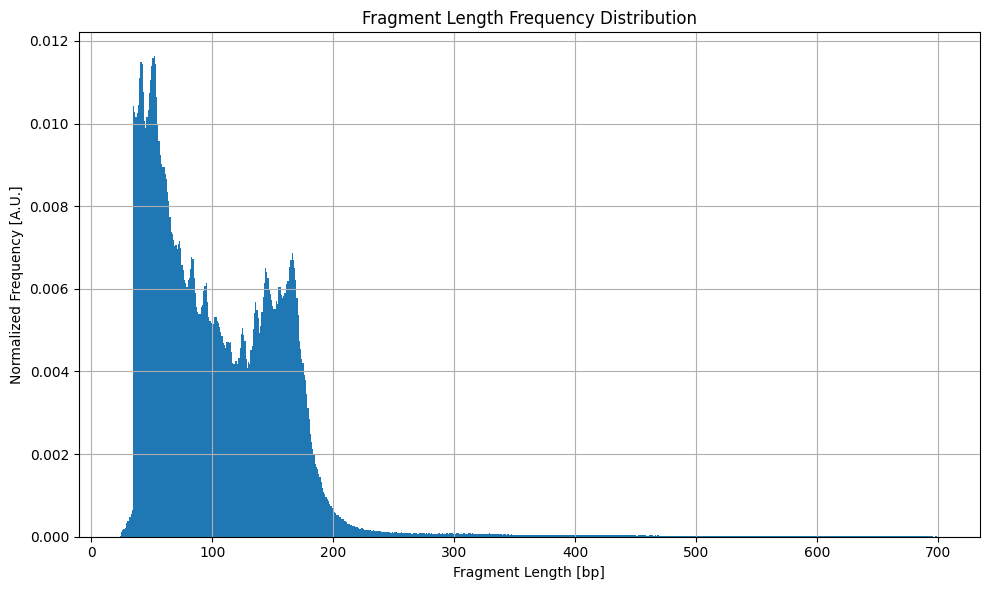

In [3]:
import matplotlib.pyplot as plt
from collections import Counter
import gzip

file_path = '/content/query.bed'
# Step 1: Read data
fragment_lengths = []
with open(file_path, "r") as file:
    for line in file:
        parts = line.strip().split('\t')
         # Check if the line has enough fields
        if len(parts) >= 3:
            try:
                start = int(parts[1])
                end = int(parts[2])
                length = end - start
                fragment_lengths.append(length)
            except ValueError:
                print(f"Skipping line due to ValueError: {line.strip()}") # Print problematic line
                continue
        else:
            print(f"Skipping line due to insufficient fields: {line.strip()}") # Print problematic line
            continue

# Step 2: Count frequency of each length
length_counts = Counter(fragment_lengths)

# Step 3: Normalize frequencies
total_fragments = sum(length_counts.values())
normalized_freq = {length: count / total_fragments for length, count in length_counts.items()}

# Step 4: Sort by fragment length for plotting
sorted_lengths = sorted(normalized_freq.keys())
normalized_values = [normalized_freq[length] for length in sorted_lengths]

# Step 5: Plot
plt.figure(figsize=(10, 6))
plt.bar(sorted_lengths, normalized_values, width=1.0)
plt.xlabel("Fragment Length [bp]")
plt.ylabel("Normalized Frequency [A.U.]")
plt.title("Fragment Length Frequency Distribution")
plt.grid(True)
plt.tight_layout()
plt.show()



**Goal**

The objective is to rescale a set of query DNA fragments such that their length distribution closely matches a given reference distribution. This is achieved by subsampling the query fragments to conform to the reference histogram and then plotting the distributions for comparison.


**Approach**

1.Load the Reference Histogram



*  Read reference.hist into a dictionary mapping each fragment length to its normalized frequency.




2.Parse the Query BED File and Group by Length


*   Read each line from the query.bed file.
*   Compute the fragment length (end - start) and group the full lines by length using a defaultdict(list).





3.Compute the Query Distribution


*   Count how many fragments belong to each length.
*   Normalize these counts by the total number of fragments to compute the query’s empirical frequency distribution.






4.Determine a Global Scaling Factor



*   For each length present in both reference and query, compute the ratio of reference frequency to query frequency.
*   The smallest such ratio is used as a global scale factor to ensure we do not oversample any length class during subsampling.



5.Subsample Query Fragments to Match Reference

For each fragment length in the reference:

Calculate the number of fragments needed from the query using the scale factor.

Randomly sample from the available query fragments of that length, if enough exist.

6.Collect all sampled fragments into a new list.

Compute and Normalize the Rescaled Distribution

Extract fragment lengths from the resampled data.

Count and normalize the distribution just like before.

7.Plot the Distributions

Plot three lines:

Reference: Dashed black line.

Original query: Dotted red line.

Rescaled query: Solid blue line.

X-axis: Fragment length [bp]

Y-axis: Normalized frequency [A.U.]



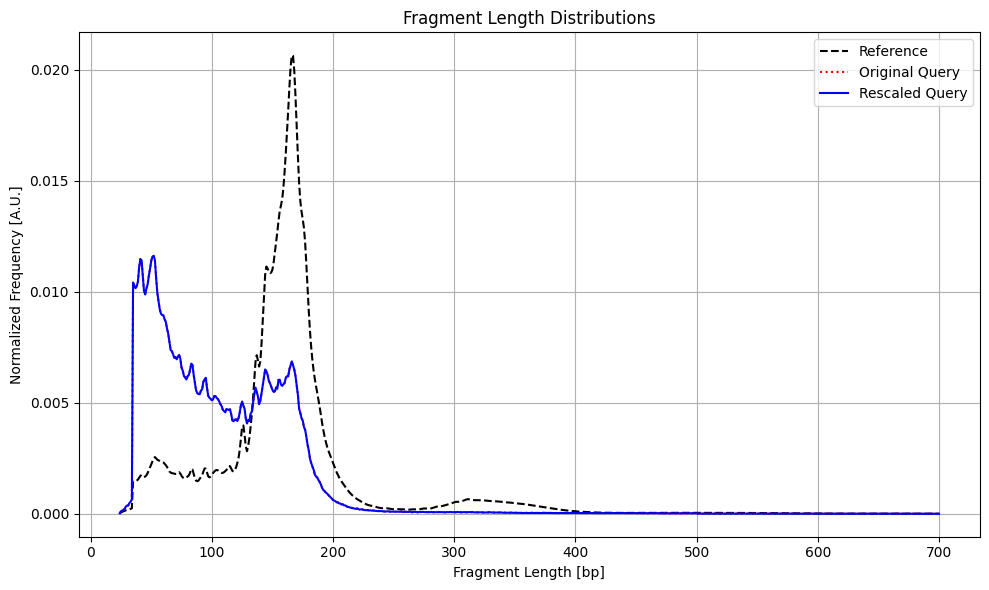

In [4]:
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import random

# Step 1: Load reference histogram
reference_hist = {}
with open("reference.hist", "r") as ref_file:
    for line in ref_file:
        if line.strip():
            length, freq = line.strip().split()
            reference_hist[int(length)] = float(freq)

# Step 2: Load query BED and compute fragment lengths
query_fragments = defaultdict(list)  # maps length to list of lines
with open("query.bed", "r") as query_file:
    for line in query_file:
        parts = line.strip().split()
        if len(parts) >= 3:
            try:
                start = int(parts[1])
                end = int(parts[2])
                length = end - start
                if length > 0:
                    query_fragments[length].append(line.strip())
            except ValueError:
                continue

# Step 3: Normalize query distribution
query_counts = {length: len(lines) for length, lines in query_fragments.items()}
total_query = sum(query_counts.values())
query_freqs = {length: count / total_query for length, count in query_counts.items()}

# Step 4: Rescale (subsample) query to match reference
# Determine the smallest scale factor to avoid oversampling
scale_factors = []
for length in reference_hist:
    if length in query_freqs and query_freqs[length] > 0:
        scale_factors.append(reference_hist[length] / query_freqs[length])
scale_factor = min(scale_factors) if scale_factors else 0

# Resample accordingly
rescaled_fragments = []
for length in reference_hist:
    if length in query_fragments:
        target_fraction = reference_hist[length]
        num_to_sample = int(target_fraction / scale_factor * total_query)
        available_fragments = query_fragments[length]
        if num_to_sample > len(available_fragments):
            sampled = available_fragments  # Use all available
        else:
            sampled = random.sample(available_fragments, num_to_sample)
        rescaled_fragments.extend(sampled)

# Step 5: Compute fragment length distribution of rescaled data
rescaled_lengths = [int(line.split()[2]) - int(line.split()[1]) for line in rescaled_fragments]
rescaled_counts = Counter(rescaled_lengths)
total_rescaled = sum(rescaled_counts.values())
normalized_rescaled = {length: count / total_rescaled for length, count in rescaled_counts.items()}

# Step 6: Plot all three distributions
plt.figure(figsize=(10, 6))

# Reference distribution
ref_lengths = sorted(reference_hist.keys())
ref_values = [reference_hist[length] for length in ref_lengths]
plt.plot(ref_lengths, ref_values, label="Reference", color='black', linestyle='--')

# Original query distribution
orig_lengths = sorted(query_freqs.keys())
orig_values = [query_freqs[length] for length in orig_lengths]
plt.plot(orig_lengths, orig_values, label="Original Query", color='red', linestyle=':')

# Rescaled query distribution
res_lengths = sorted(normalized_rescaled.keys())
res_values = [normalized_rescaled.get(length, 0) for length in res_lengths]
plt.plot(res_lengths, res_values, label="Rescaled Query", color='blue')

# Plot decorations
plt.xlabel("Fragment Length [bp]")
plt.ylabel("Normalized Frequency [A.U.]")
plt.title("Fragment Length Distributions")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
